In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline # Step by step data flow
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, recall_score, precision_score, roc_curve, auc, roc_auc_score

In [2]:
df = pd.read_csv('../data/telco_churn_data.csv')

In [3]:
df.head(2)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No


In [4]:
df.shape

(7043, 21)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [6]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [7]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
original_rows = len(df)
df = df.dropna(subset=['TotalCharges'])
print(f"Total dropped rows with NaNs: {original_rows - len(df)}")

Total dropped rows with NaNs: 11


In [8]:
df.shape

(7032, 21)

In [9]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [10]:
target_feature = 'Churn'
numeric_features = ['MonthlyCharges', 'TotalCharges', 'tenure']
categorical_features = ['gender', 'SeniorCitizen', 'Partner', 'Dependents',
      'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod']

In [13]:
import warnings
warnings.filterwarnings('ignore')

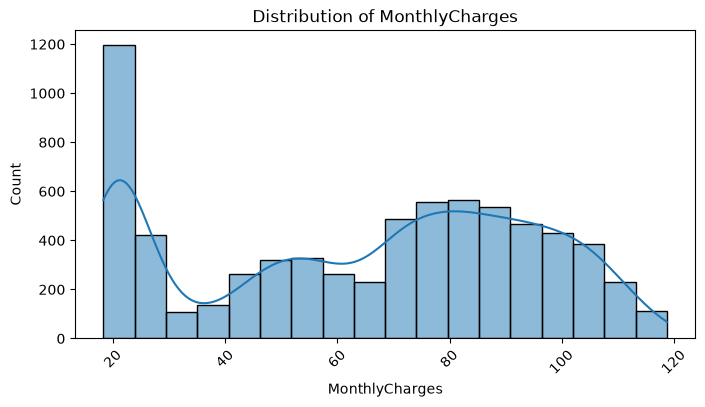

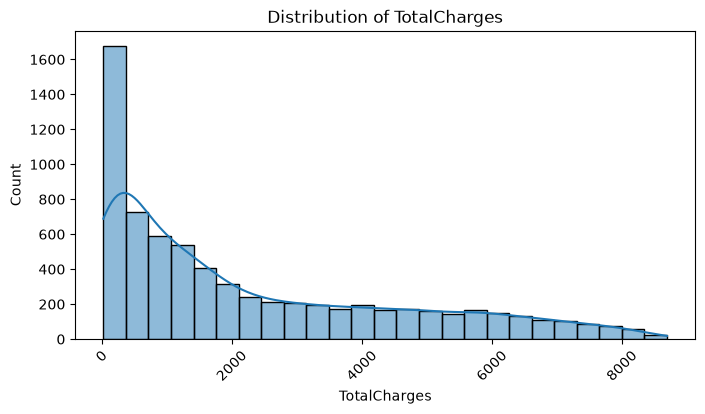

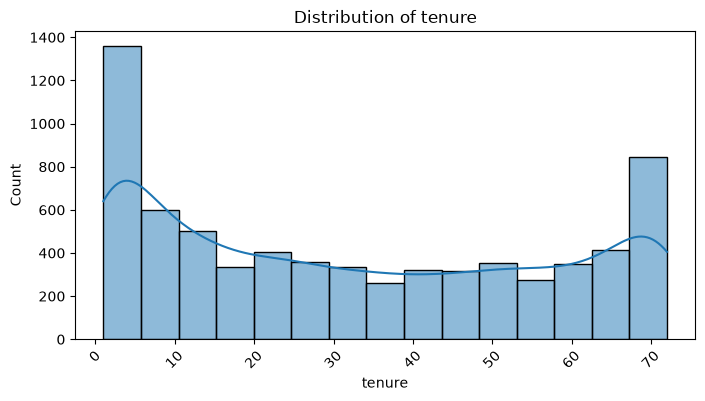

In [14]:
for feature in numeric_features:
    plt.figure(figsize=(8, 4))
    sns.histplot(data=df, x=feature, kde=True, palette='Set2')
    plt.title(f'Distribution of {feature}')
    plt.xticks(rotation=45) # Useful for longer labels like PaymentMethod
    plt.show()

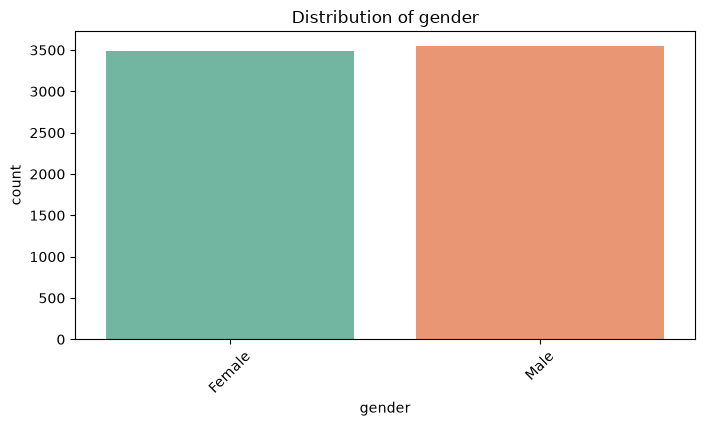

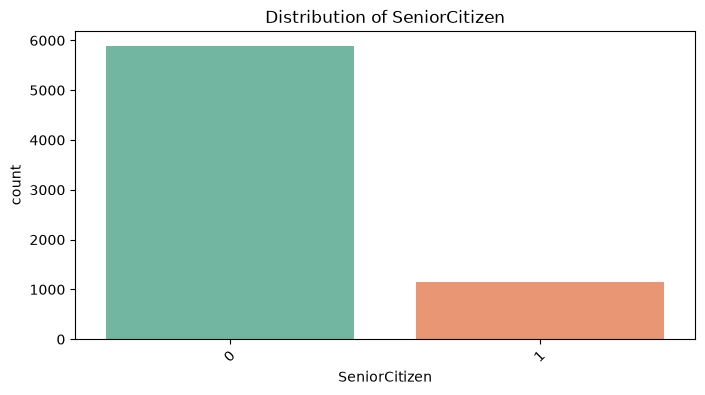

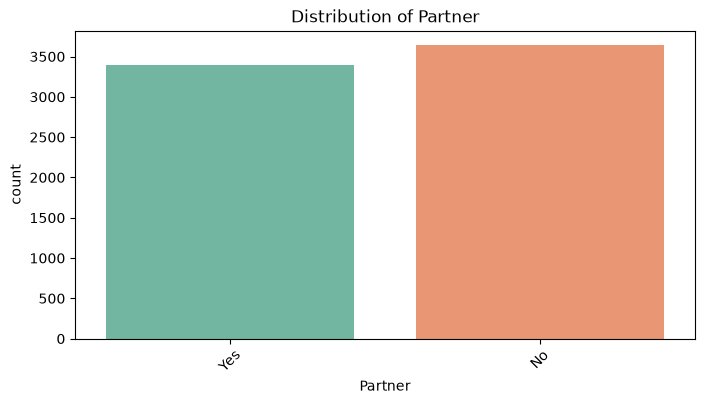

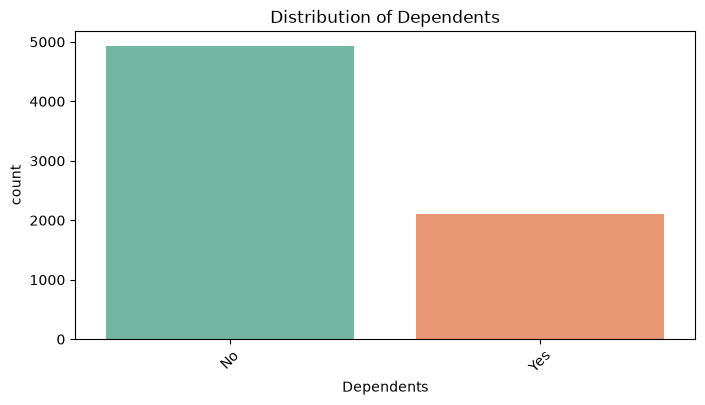

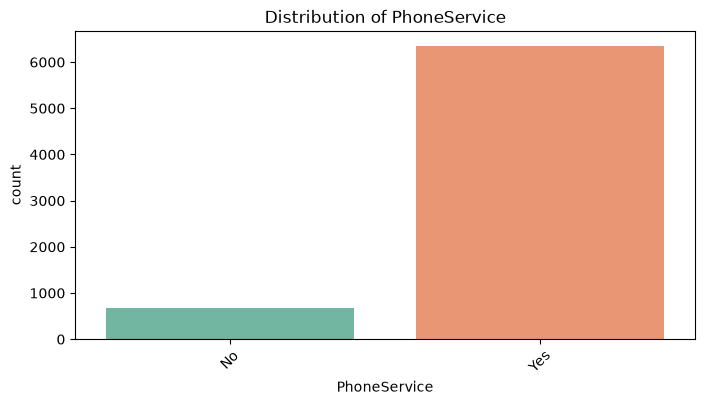

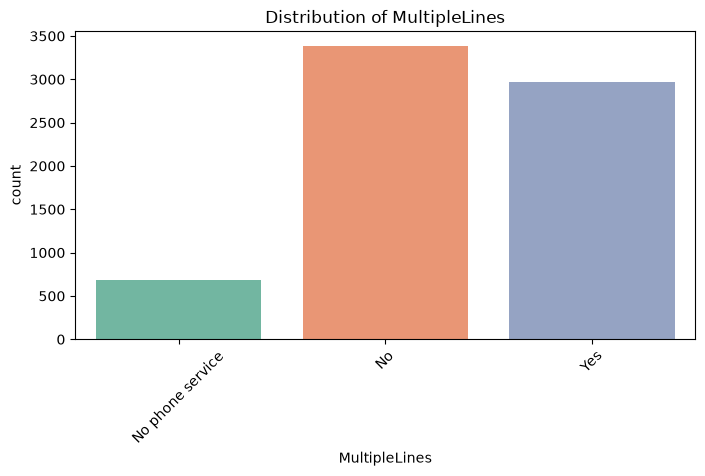

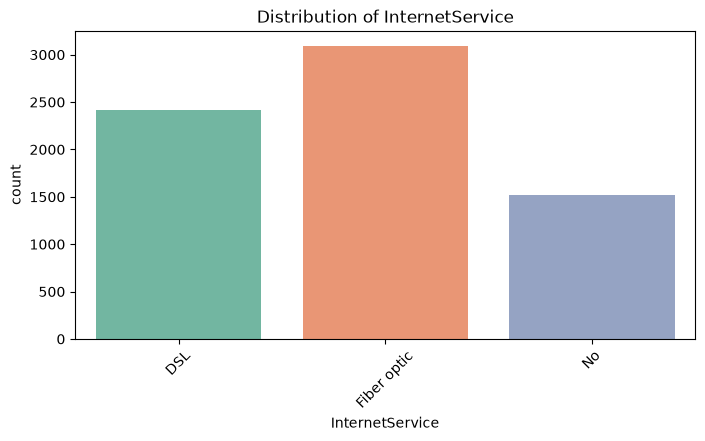

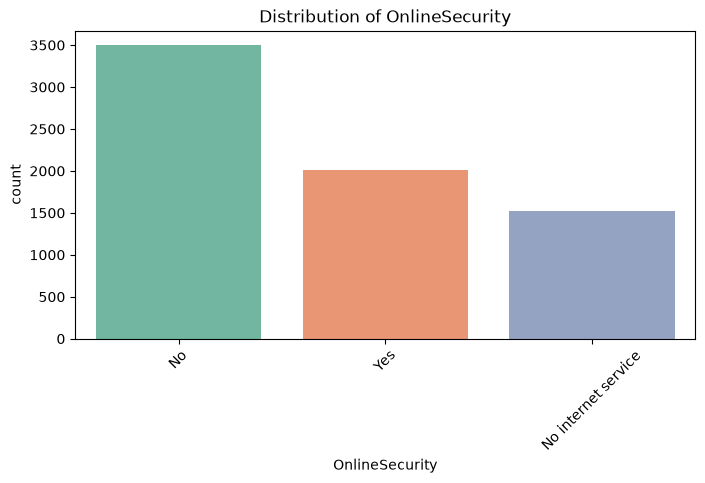

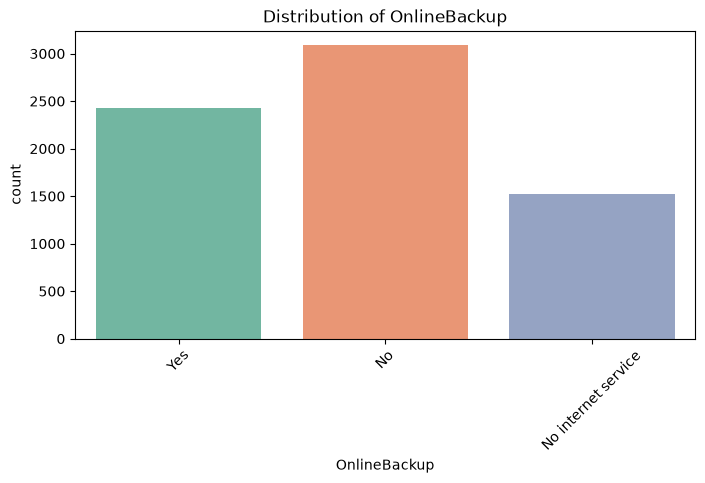

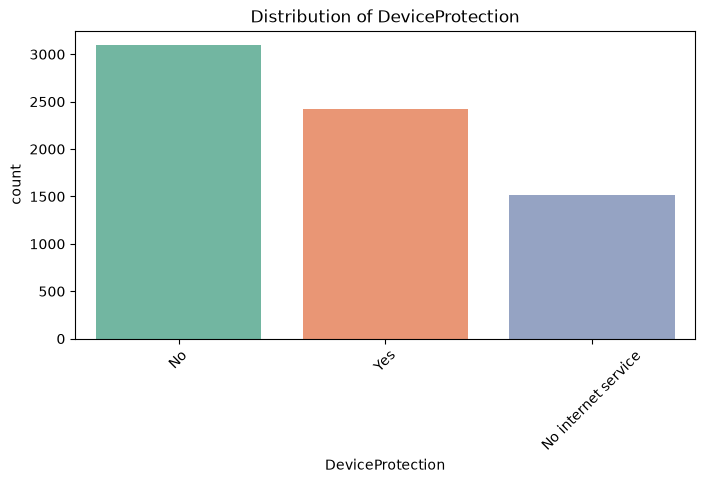

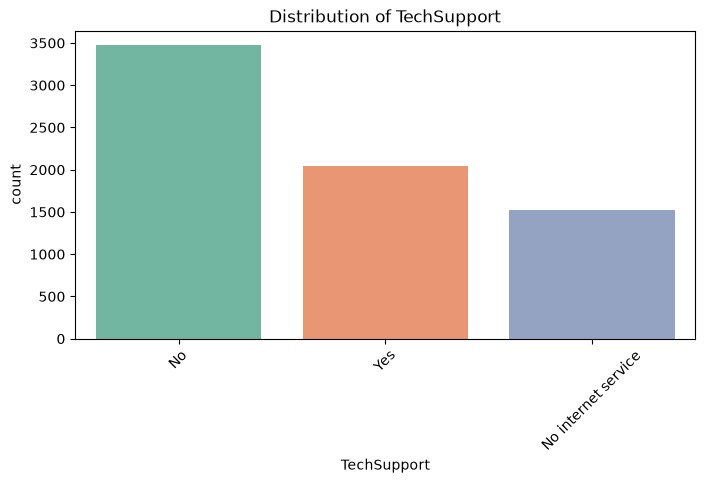

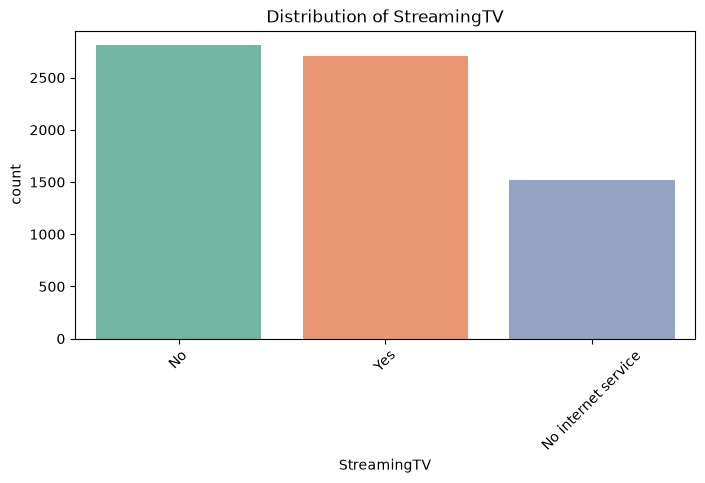

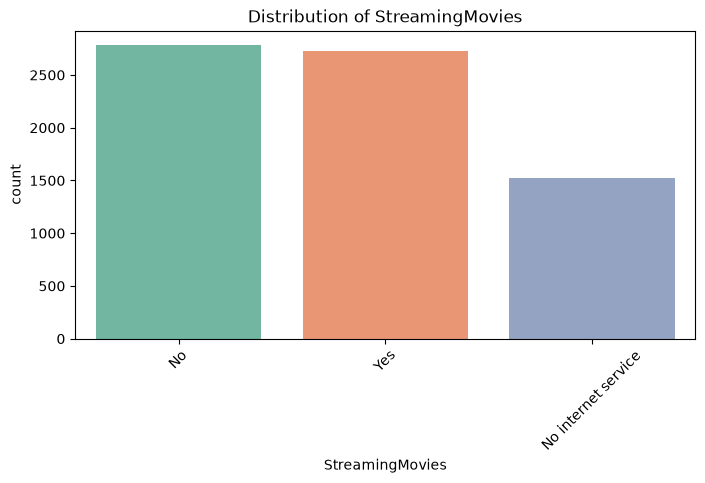

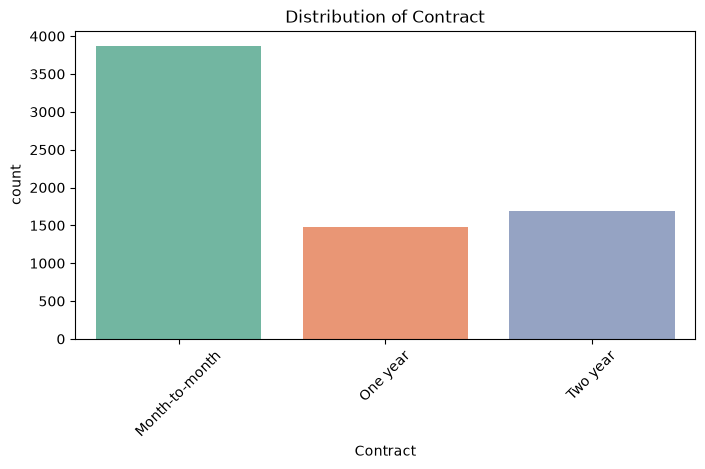

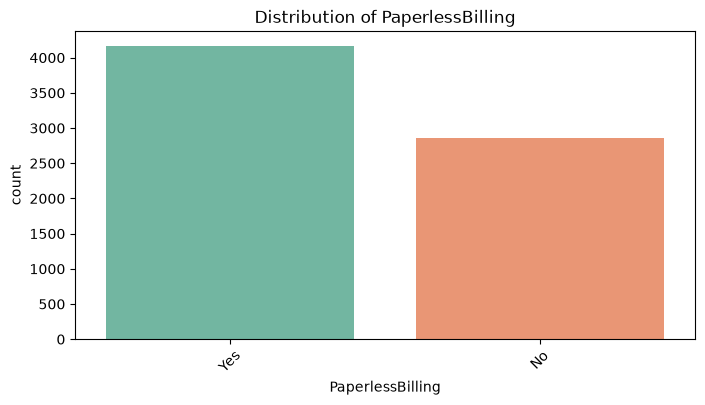

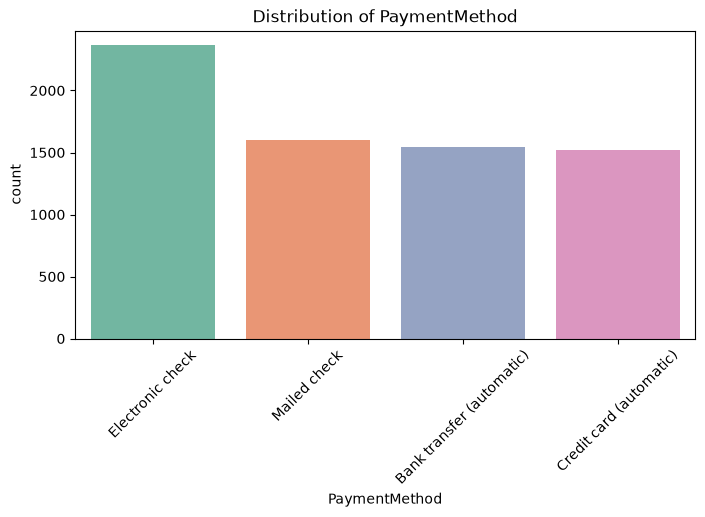

In [15]:
for feature in categorical_features:
    plt.figure(figsize=(8, 4))
    sns.countplot(data=df, x=feature, palette='Set2')
    plt.title(f'Distribution of {feature}')
    plt.xticks(rotation=45) # Useful for longer labels like PaymentMethod
    plt.show()

In [16]:
X = df[numeric_features + categorical_features]
y = df[target_feature]

In [17]:
y.head()

0     No
1     No
2    Yes
3     No
4    Yes
Name: Churn, dtype: str

In [18]:
from collections import Counter
Counter(y)
#The data is imbalanced since yes and no are not 50-50

Counter({'No': 5163, 'Yes': 1869})

In [19]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.3, stratify=y)
#In train_test_split, the stratify parameter ensures that the proportions of class labels in the training and testing sets are approximately the same as the proportions in the original dataset.

In [20]:
y_train = y_train.map({'Yes': 1, 'No': 0})
y_test = y_test.map({'Yes': 1, 'No': 0})
y = y.map({'Yes': 1, 'No': 0})

In [21]:
print(f"Original data churn rate: {y.mean():.2f}")
print(f"Training data churn rate: {y_train.mean():.2f}")
print(f"Testing data churn rate: {y_test.mean():.2f}")

Original data churn rate: 0.27
Training data churn rate: 0.27
Testing data churn rate: 0.27


In [22]:
from sklearn.compose import ColumnTransformer
# Numeric Preprocessing Batch

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
# Categorical Preprocessing Batch

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])
# Combine both batches with ColumnTransformer

preprocessor = ColumnTransformer(
    transformers = [
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)

    ],
    remainder = 'drop'
)

# Create the final, full-stack pipeline
clf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        class_weight = 'balanced',
        random_state = 42,
    ))
])

In [23]:
clf_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [24]:
y_predict = clf_pipeline.predict(X_test)
print(y_predict)

[1 0 0 ... 0 0 0]


In [26]:
y_proba = clf_pipeline.predict_proba(X_test)[:,1]
print(y_proba)

[0.58438777 0.05619725 0.03146326 ... 0.09123244 0.38516569 0.49951573]


In [27]:
print(recall_score(y_test, y_predict))

0.7878787878787878


In [28]:
print(confusion_matrix(y_test, y_predict))

[[1108  441]
 [ 119  442]]


In [29]:
print(precision_score(y_test, y_predict))

0.5005662514156285


In [30]:
print(accuracy_score(y_test, y_predict))

0.7345971563981043


In [31]:
print(f1_score(y_test, y_predict))

0.6121883656509696


In [32]:
print(classification_report(y_test, y_predict))

              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1549
           1       0.50      0.79      0.61       561

    accuracy                           0.73      2110
   macro avg       0.70      0.75      0.71      2110
weighted avg       0.80      0.73      0.75      2110



In [33]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)
print(roc_auc)

0.8380796534823802


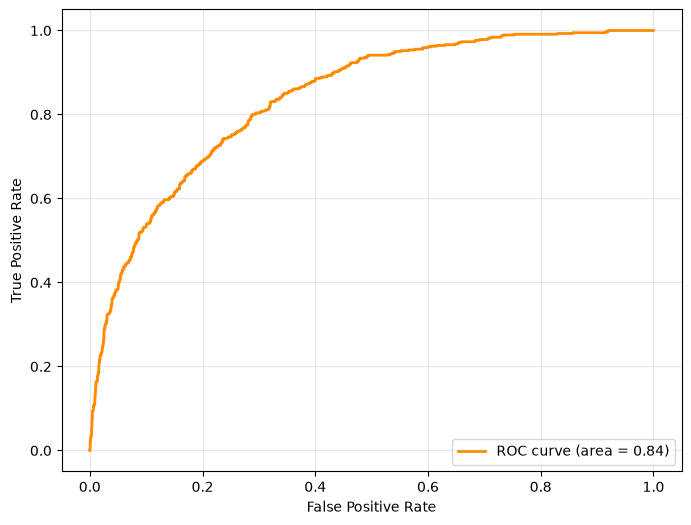

In [34]:
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

In [35]:
rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators = 200,
        class_weight = 'balanced',
        random_state = 42,

    ))
])

In [36]:
rf_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [37]:
y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

In [38]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1549
           1       0.63      0.51      0.56       561

    accuracy                           0.79      2110
   macro avg       0.73      0.70      0.71      2110
weighted avg       0.78      0.79      0.78      2110



In [39]:
print(confusion_matrix(y_test, y_pred_rf))

[[1377  172]
 [ 273  288]]


In [40]:
fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, y_proba_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)
print(roc_auc_rf)

0.8187301565382301


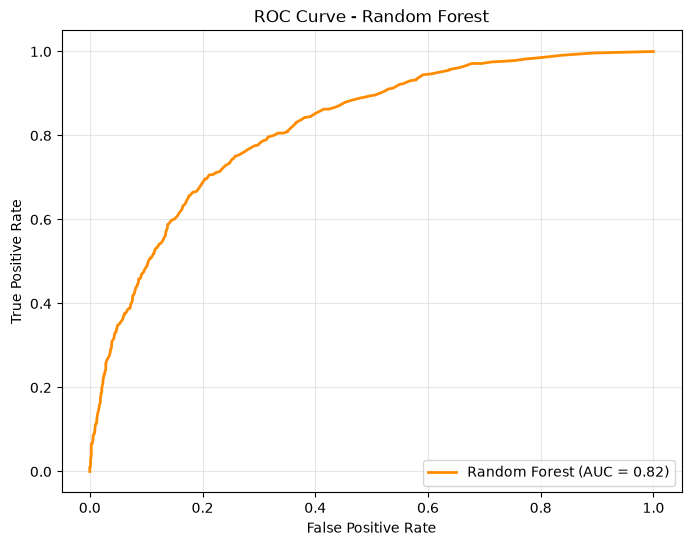

In [41]:
plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, color='darkorange', lw=2, label=f"Random Forest (AUC = {roc_auc_rf:.2f})")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

In [42]:
from sklearn.model_selection import cross_val_score

cv_auc = cross_val_score(
    clf_pipeline, X_train, y_train,
    scoring='roc_auc',
    cv=5
)
print("Logistic Regression CV AUC:", cv_auc.mean())

Logistic Regression CV AUC: 0.846443264323334


In [43]:
cv_auc = cross_val_score(
    rf_model, X_train, y_train,
    scoring='roc_auc',
    cv=5
)
print("Random Forest CV AUC:", cv_auc.mean())

Random Forest CV AUC: 0.8229432203843448


In [44]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'model__n_estimators': [200, 400],
    'model__max_depth': [None, 10, 20],
    'model__min_samples_split': [2, 10],
    'model__min_samples_leaf': [1, 5]
}

In [45]:
grid_rf = GridSearchCV(
    rf_model,
    param_grid,
    scoring='roc_auc',
    cv=3,
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'model__max_depth': [None, 10, ...], 'model__min_samples_leaf': [1, 5], 'model__min_samples_split': [2, 10], 'model__n_estimators': [200, 400]}"
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [46]:
print("Best RF Params:", grid_rf.best_params_)
print("Best RF CV AUC:", grid_rf.best_score_)

Best RF Params: {'model__max_depth': None, 'model__min_samples_leaf': 5, 'model__min_samples_split': 2, 'model__n_estimators': 200}
Best RF CV AUC: 0.8469792465144778


In [47]:
best_rf = grid_rf.best_estimator_

y_pred_rf = best_rf.predict(X_test)
y_pred_proba_rf = best_rf.predict_proba(X_test)[:, 1]

fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, y_pred_proba_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)
print(roc_auc_rf)
print(accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

0.8385255739715922
0.7725118483412322
              precision    recall  f1-score   support

           0       0.88      0.79      0.84      1549
           1       0.56      0.71      0.63       561

    accuracy                           0.77      2110
   macro avg       0.72      0.75      0.73      2110
weighted avg       0.80      0.77      0.78      2110



In [48]:
feature_names = best_rf.named_steps['preprocessor'].get_feature_names_out()
importances = best_rf.named_steps['model'].feature_importances_

feat_imp = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)

feat_imp.head(15)

,feature,importance
2,num__tenure,0.132310
37,cat__Contract_Month-to-month,0.113299
1,num__TotalCharges,0.110887
0,num__MonthlyCharges,0.077989
39,cat__Contract_Two year,0.059688
19,cat__OnlineSecurity_No,0.048355
28,cat__TechSupport_No,0.045149
17,cat__InternetService_Fiber optic,0.040522
44,cat__PaymentMethod_Electronic check,0.031018
16,cat__InternetService_DSL,0.021580


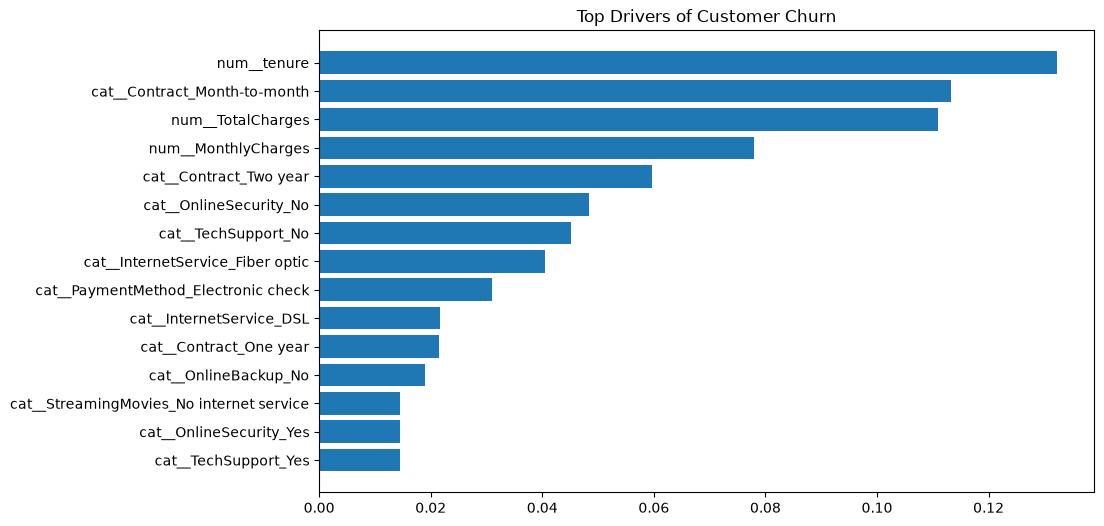

In [49]:
top_features = feat_imp.head(15)
plt.figure(figsize=(10, 6))
plt.barh(top_features['feature'], top_features['importance'])
plt.gca().invert_yaxis()
plt.title("Top Drivers of Customer Churn")
plt.show()

In [50]:
thresholds = np.arange(0.1, 0.9, 0.05)

results = []

for t in thresholds:
    y_pred_custom = (y_pred_proba_rf >= t).astype(int)

    precision = precision_score(y_test, y_pred_custom)
    recall = recall_score(y_test, y_pred_custom)
    f1 = f1_score(y_test, y_pred_custom)

    results.append((t, precision, recall, f1))

results_df = pd.DataFrame(results, columns=["threshold", "precision", "recall", "f1"])
results_df

,threshold,precision,recall,f1
0,0.10,0.337888,0.969697,0.501152
1,0.15,0.365555,0.957219,0.529064
2,0.20,0.389843,0.930481,0.549474
3,0.25,0.416463,0.910873,0.571588
4,0.30,0.442049,0.877005,0.587814
5,0.35,0.465820,0.850267,0.601893
6,0.40,0.496739,0.814617,0.617151
7,0.45,0.528049,0.771836,0.627082
8,0.50,0.556172,0.714795,0.625585
9,0.55,0.586751,0.663102,0.622594


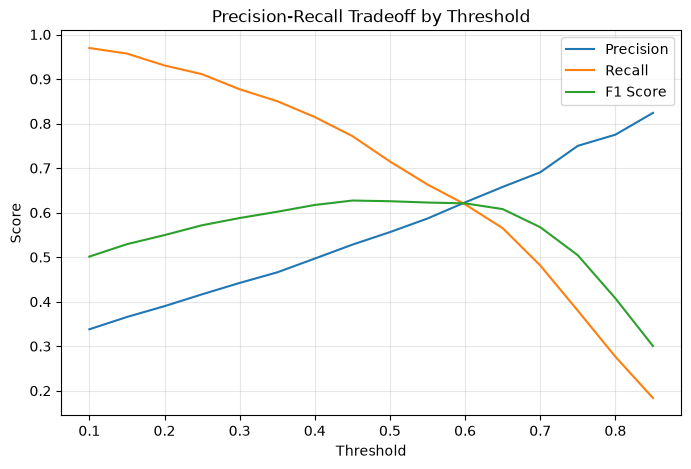

In [51]:
plt.figure(figsize=(8,5))
plt.plot(results_df["threshold"], results_df["precision"], label="Precision")
plt.plot(results_df["threshold"], results_df["recall"], label="Recall")
plt.plot(results_df["threshold"], results_df["f1"], label="F1 Score")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.legend()
plt.title("Precision-Recall Tradeoff by Threshold")
plt.grid(alpha=0.3)
plt.show()

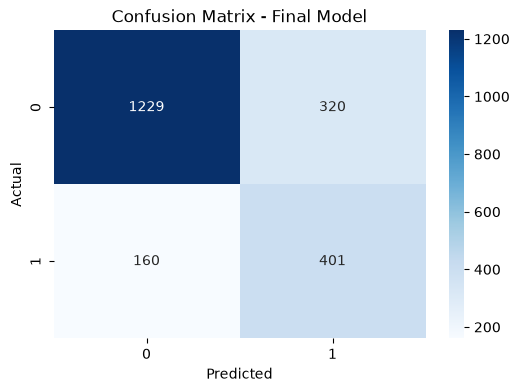

In [52]:
y_pred_final = best_rf.predict(X_test)

cm = confusion_matrix(y_test, y_pred_final)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Final Model")
plt.show()

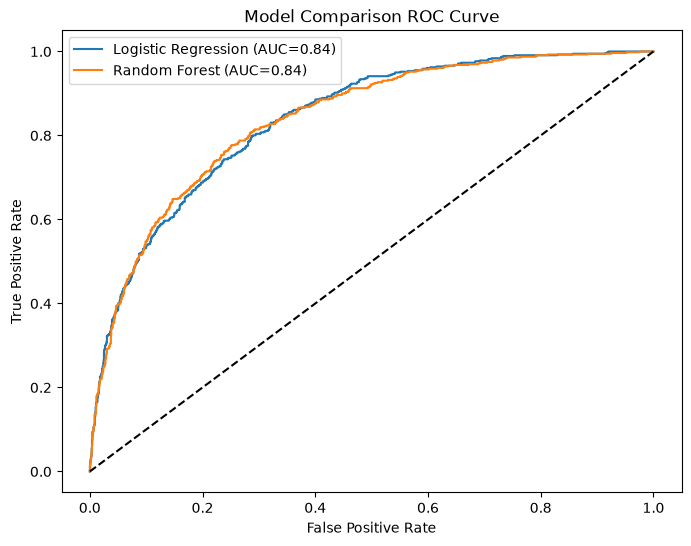

In [53]:
plt.figure(figsize=(8,6))

plt.plot(fpr, tpr, label=f"Logistic Regression (AUC={roc_auc:.2f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC={roc_auc_rf:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Model Comparison ROC Curve")
plt.legend()
plt.show()

In [54]:
churn_prob = y_pred_proba_rf

risk_df = pd.DataFrame({
    "churn_probability": churn_prob
})

risk_df["risk_level"] = pd.cut(
    risk_df["churn_probability"],
    bins=[0,0.3,0.6,1],
    labels=["Low Risk","Medium Risk","High Risk"]
)

risk_df["risk_level"].value_counts()

risk_level
Low Risk       995
High Risk      557
Medium Risk    556
Name: count, dtype: int64

In [55]:
import joblib

joblib.dump(clf_pipeline, "logistic_model.pkl")
joblib.dump(best_rf, "rf_model.pkl")

['rf_model.pkl']

In [56]:
import sklearn
print(sklearn.__version__)

1.7.2


In [57]:
import shap
X_train_transformed = best_rf.named_steps['preprocessor'].transform(X_train)

In [58]:
feature_names = best_rf.named_steps['preprocessor'].get_feature_names_out()

In [59]:
rf_classifier = best_rf.named_steps['model']
explainer = shap.TreeExplainer(rf_classifier)
shap_values = explainer.shap_values(X_train_transformed)

In [60]:
print(type(shap_values))
print(len(shap_values))
print(shap_values[1].shape)
print(X_train_transformed.shape)

<class 'numpy.ndarray'>
4922
(46, 2)
(4922, 46)


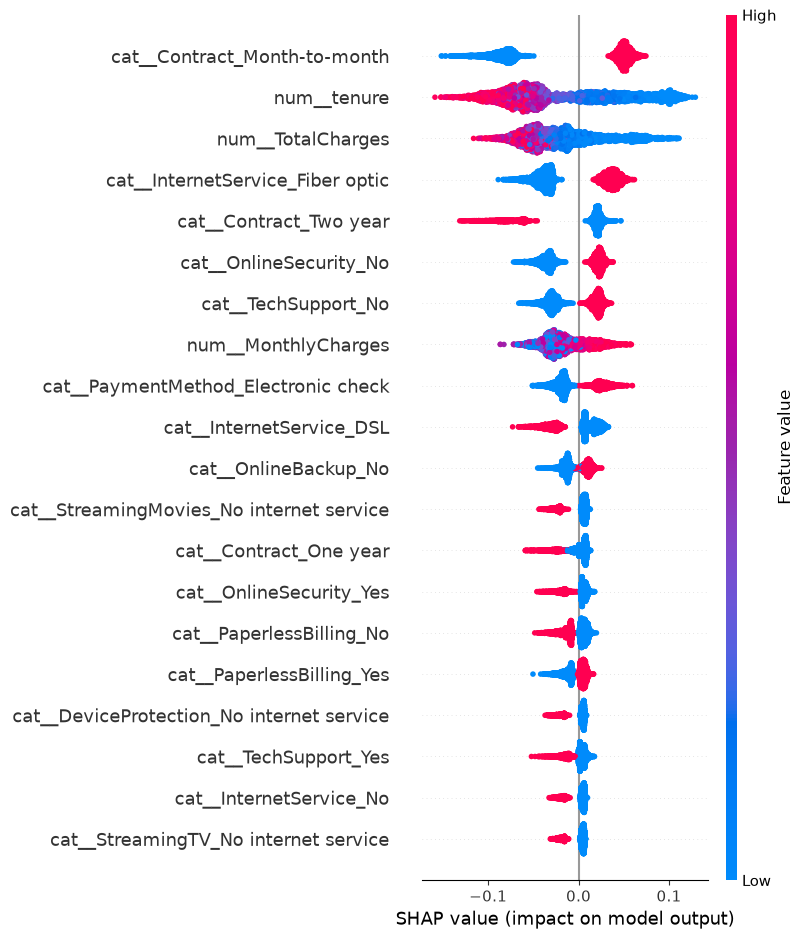

In [61]:
shap.summary_plot(
    shap_values[:, :, 1],
    X_train_transformed,
    feature_names=feature_names
)

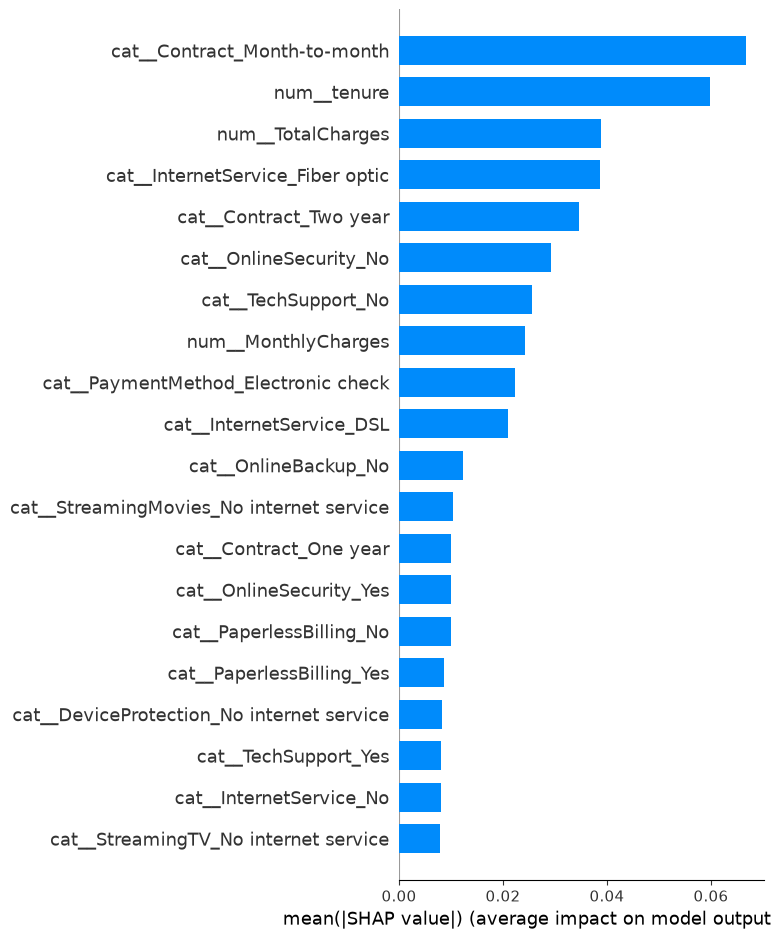

In [62]:
shap.summary_plot(
    shap_values[:, :, 1],
    X_train_transformed,
    feature_names=feature_names,
    plot_type="bar"
)

In [63]:
neg, pos = np.bincount(y_train)
scale_pos_weight = neg / pos

In [64]:
xgb_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', XGBClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        eval_metric='logloss'
    ))
])

In [65]:
xgb_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [66]:
y_pred_xgb = xgb_model.predict(X_test)
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_xgb))
print("ROC AUC:", roc_auc_score(y_test, y_proba_xgb))

              precision    recall  f1-score   support

           0       0.90      0.75      0.82      1549
           1       0.53      0.78      0.63       561

    accuracy                           0.75      2110
   macro avg       0.71      0.76      0.72      2110
weighted avg       0.80      0.75      0.77      2110

ROC AUC: 0.8391941670147725


In [68]:
joblib.dump(xgb_model, "xgb_model.pkl")

['xgb_model.pkl']

In [67]:
performance_df = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "XGBoost"],
    "ROC AUC": [0.86, 0.85, round(roc_auc_score(y_test, y_proba_xgb), 2)],
    "F1 Score": [0.64, 0.65, round(f1_score(y_test, y_pred_xgb), 2)],
    "Precision": [0.52, 0.56, round(precision_score(y_test, y_pred_xgb), 2)],
    "Recall": [0.84, 0.78, round(recall_score(y_test, y_pred_xgb), 2)]
})
performance_df

,Model,ROC AUC,F1 Score,Precision,Recall
0,Logistic Regression,0.86,0.64,0.52,0.84
1,Random Forest,0.85,0.65,0.56,0.78
2,XGBoost,0.84,0.63,0.53,0.78
